In [54]:
import json 
import os 
import numpy as np 
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

tr = pd.read_parquet("../data/interim/transcripts.parquet")
un = pd.read_parquet("../data/interim/un_panel.parquet")
t1 = pd.read_parquet("../data/features/tier1.parquet")

print("Transcripts:", tr.shape)
print("UN:", un.shape)
print("Tier1:", t1.shape)

print("\nTranscript columns:")
print(tr.columns.tolist())

print("\nUN columns:")
print(un.columns.tolist())

print("\nTier1 columns:")
print(t1.columns.tolist())

Transcripts: (910, 9)
UN: (244, 8)
Tier1: (26, 12)

Transcript columns:
['year', 'meeting_n', 'meeting_id', 'segment', 'n_pages', 'text', 'n_chars', 'sha256', 'source_pdf']

UN columns:
['agency', 'year', 'revenue_usd', 'n_subagencies', 'rev_assessed_contributions', 'rev_revenue_from_other_activities', 'rev_voluntary_core_(un_earmarked)_contributions', 'rev_voluntary_non_core_(earmarked)_contributions']

Tier1 columns:
['year', 'segment', 'n_meetings', 'n_tokens', 'sentiment', 'lex_development', 'lex_humanitarian', 'lex_climate', 'lex_gender', 'lex_conflict', 'lex_health', 'lex_governance']


### Step 1: Corpus Statistics from Transcript

In [40]:
# Aggregate transcript statistics by year
by_year = tr.groupby("year").agg(
    transcript_count=("meeting_id", "count"),
    n_meetings=("meeting_n", "nunique"),
    total_chars=("n_chars", "sum"),
    avg_chars=("n_chars", "mean"),
    total_pages=("n_pages", "sum"),
    avg_pages=("n_pages", "mean")
).reset_index()

by_year

,year,transcript_count,n_meetings,total_chars,avg_chars,total_pages,avg_pages
0,2000,2,2,48670,24335.000000,13,6.500000
1,2001,36,36,1034481,28735.583333,395,10.972222
2,2002,44,44,1658849,37701.113636,408,9.272727
3,2003,45,45,1334765,29661.444444,552,12.266667
4,2004,54,54,1792091,33186.870370,454,8.407407
5,2005,41,41,1340957,32706.268293,341,8.317073
6,2006,47,47,1546044,32894.553191,642,13.659574
7,2007,43,43,1410895,32811.511628,529,12.302326
8,2008,48,48,1541204,32108.416667,380,7.916667
9,2009,47,47,1859869,39571.680851,465,9.893617


##### Corpus Summary Statistics

Transcript count remains relatively stable across most years, with approximately 40--55 transcripts annually, although some years contain fewer observations and may reflect incomplete coverage. In contrast, transcript length increases substantially over time, suggesting that corpus growth is driven primarily by richer and more detailed discussions rather than increases in meeting frequency. Overall, the corpus displays meaningful temporal variation suitable for later analysis.

### Step 2: UN Revenue Summary 

In [42]:
# Aggregate UN revenue statistics by year
by_year_un = un.groupby("year").agg(
    total_revenue=("revenue_usd", "sum"),
    avg_agency_revenue=("revenue_usd", "mean"),
    median_agency_revenue=("revenue_usd", "median"),
    n_agencies=("agency", "nunique")
).reset_index()

by_year_un

,year,total_revenue,avg_agency_revenue,median_agency_revenue,n_agencies
0,2011,2.381769e+10,1.488605e+09,7.151918e+08,16
1,2012,2.503346e+10,1.564592e+09,8.791529e+08,16
2,2013,2.754187e+10,1.721367e+09,8.987789e+08,16
3,2014,2.872140e+10,1.795088e+09,9.253186e+08,16
4,2015,2.770679e+10,1.731674e+09,8.895972e+08,16
5,2016,2.932663e+10,1.832914e+09,8.080776e+08,16
6,2017,3.259105e+10,1.810614e+09,6.753630e+08,18
7,2018,3.487618e+10,1.937565e+09,7.168378e+08,18
8,2019,3.516366e+10,1.953537e+09,7.692744e+08,18
9,2020,4.057379e+10,2.254099e+09,7.712957e+08,18


#### Concentration 

In [44]:
# Total revenue by agency
agency_totals = (
    un.groupby("agency")["revenue_usd"]
    .sum()
    .sort_values(ascending=False)
)

agency_totals.head(10)

agency
WFP       1.034105e+11
UNICEF    9.125031e+10
UNDP      7.486862e+10
UNHCR     5.680076e+10
WHO       4.292736e+10
FAO       2.382883e+10
UNFPA     1.789474e+10
UNRWA     1.629166e+10
ILO       1.068363e+10
UNEP      1.035684e+10
Name: revenue_usd, dtype: float64

#### Visualizations

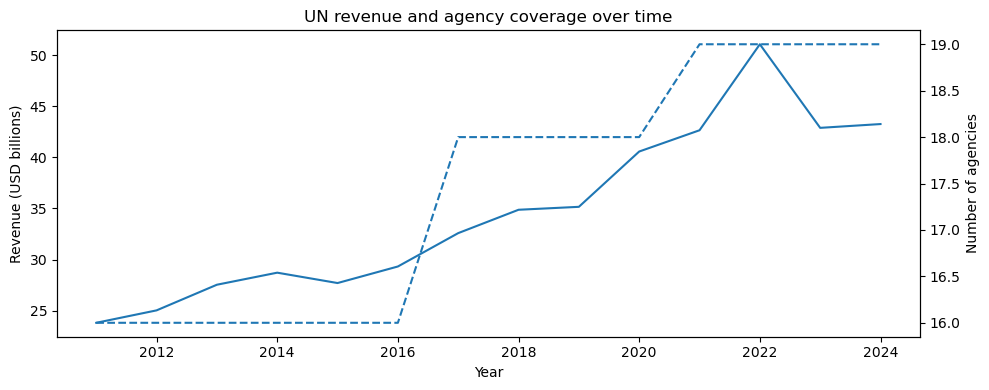

In [45]:
fig, ax1 = plt.subplots(figsize=(10,4))

# Left axis: revenue
ax1.plot(by_year_un["year"],
         by_year_un["total_revenue"] / 1e9)

ax1.set_xlabel("Year")
ax1.set_ylabel("Revenue (USD billions)")

# Right axis: agency count
ax2 = ax1.twinx()
ax2.plot(
    by_year_un["year"],
    by_year_un["n_agencies"],
    linestyle="--"
)

ax2.set_ylabel("Number of agencies")

plt.title("UN revenue and agency coverage over time")

plt.tight_layout()
plt.show()

##### UN Revenue and Agency Coverage Over Time

Total UN revenue increases substantially over the sample period, rising from roughly \$24 billion to over \$40 billion and peaking around \$51 billion in 2022. In contrast, agency coverage changes only modestly, increasing from 16 to 19 agencies. This suggests that growth in total funding primarily reflects increased revenues among existing agencies rather than changes in dataset composition.

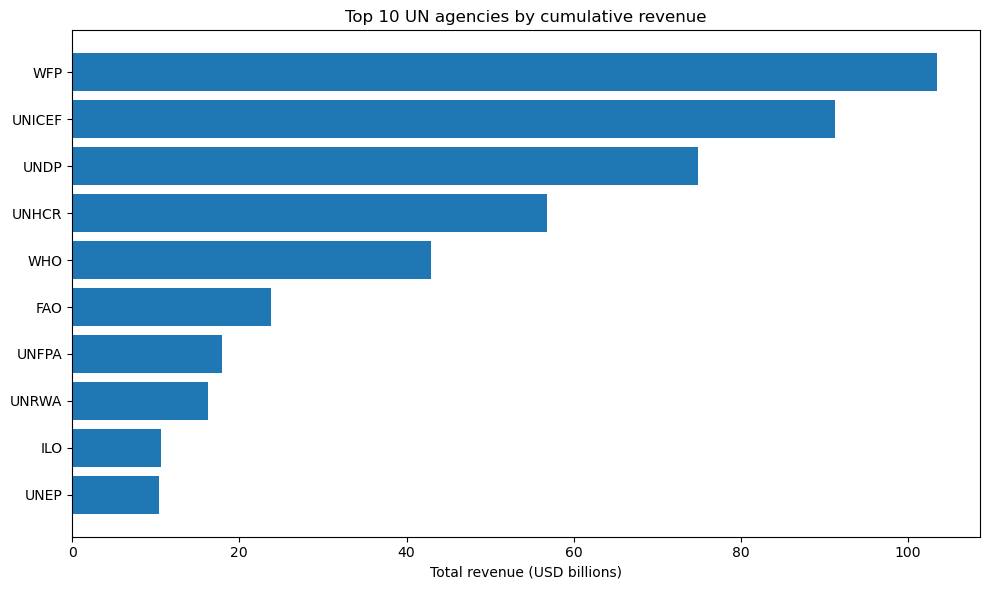

In [46]:
# Top 10 agencies by cumulative revenue
agency_totals = (
    un.groupby("agency")["revenue_usd"]
    .sum()
    .sort_values(ascending=False)
)

top10 = agency_totals.head(10)

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(top10.index, top10.values / 1e9)

ax.set_xlabel("Total revenue (USD billions)")
ax.set_title("Top 10 UN agencies by cumulative revenue")

ax.invert_yaxis()

plt.tight_layout()
plt.show()

##### Revenue Concentration Across UN Agencies

UN funding is highly concentrated among a small subset of agencies, with WFP, UNICEF, UNDP, and UNHCR receiving substantially larger cumulative revenues than other organizations. This strong concentration indicates a highly skewed funding distribution and motivates the use of log-transformed revenue in later analyses.

### Step 3: Load and fix World Bank project data 

The World Bank project files required preprocessing because funding amounts
were stored as strings with commas. We cleaned these values and converted
them to numeric format prior to analysis.

In [8]:
rows = []

for fname in sorted(os.listdir("../data/raw/wb_projects")):
    
    if not fname.endswith(".json"):
        continue

    with open(f"../data/raw/wb_projects/{fname}") as f:
        data = json.load(f)

    for pid, proj in data.get("projects", {}).items():

        amt_str = str(
            proj.get("totalamt", "0")
        ).replace(",", "")

        try:
            totalamt = float(amt_str) if amt_str else 0.0
        except ValueError:
            totalamt = 0.0

        sector = proj.get("sector1", {})

        sector_name = (
            sector.get("Name", "Unknown")
            if isinstance(sector, dict)
            else "Unknown"
        )

        if sector_name == "":
            sector_name = "Unknown"

        date_str = proj.get("boardapprovaldate", "")

        year = (
            int(date_str[:4])
            if date_str and len(date_str) >= 4
            else None
        )

        rows.append({
            "project_id": pid,
            "project_name": proj.get("project_name", ""),
            "country": proj.get("countryshortname", ""),
            "sector": sector_name,
            "year": year,
            "totalamt": totalamt
        })

wb_df = pd.DataFrame(rows)

wb_df = wb_df.dropna(
    subset=["year"]
)

wb_df["year"] = wb_df["year"].astype(int)

wb_df = wb_df[
    wb_df["year"] >= 2000
]

print(
    "Rows loaded:",
    len(wb_df)
)

print(
    "Total WB commitments:",
    wb_df["totalamt"].sum()
)

wb_df["totalamt"].describe()

Rows loaded: 8378
Total WB commitments: 910104610000.0


count    8.378000e+03
mean     1.086303e+08
std      1.798313e+08
min      0.000000e+00
25%      1.000000e+07
50%      4.500000e+07
75%      1.300000e+08
max      3.750000e+09
Name: totalamt, dtype: float64

In [47]:
# Examine dataset
print("Rows:", wb_df.shape[0])
print("Columns:", wb_df.columns.tolist())
print("\nYears:", wb_df["year"].min(), "-", wb_df["year"].max())
print("Unique sectors:", wb_df["sector"].nunique())
print("Unique countries:", wb_df["country"].nunique())

Rows: 8378
Columns: ['project_id', 'project_name', 'country', 'sector', 'year', 'totalamt']

Years: 2000 - 2024
Unique sectors: 71
Unique countries: 176


In [48]:
# Sector concentration
sector_summary = (
    wb_df.groupby("sector")
    .agg(
        n_projects=("project_id", "count"),
        total_commitments=("totalamt", "sum")
    )
    .sort_values("total_commitments", ascending=False)
)

sector_summary["total_commitments"] /= 1e9

print("Top 10 sectors:")
print(sector_summary.head(10))


# Country concentration
country_summary = (
    wb_df.groupby("country")
    .agg(
        n_projects=("project_id", "count"),
        total_commitments=("totalamt", "sum")
    )
    .sort_values("total_commitments", ascending=False)
)

country_summary["total_commitments"] /= 1e9

print("\nTop 10 countries:")
print(country_summary.head(10))


# Missingness
print("\nMissing values:")
print(wb_df.isna().sum())

print("\nUnknown sectors:", (wb_df["sector"] == "Unknown").sum())
print("Unknown countries:", (wb_df["country"] == "Unknown").sum())

Top 10 sectors:
                                       n_projects  total_commitments
sector                                                              
Central Government (Central Agencies)         908           89.69417
Unknown                                       371           68.39104
Social Protection                             606           65.81547
Rural and Inter-Urban Roads                   466           65.15516
Health                                        520           46.27398
Sub-National Government                       311           42.07054
Other Public Administration                   366           42.06412
Energy Transmission and Distribution          232           40.00532
Banking Institutions                          175           33.85543
Other Energy and Extractives                  225           24.27624

Top 10 countries:
            n_projects  total_commitments
country                                  
India              341           75.22430
Indonesia  

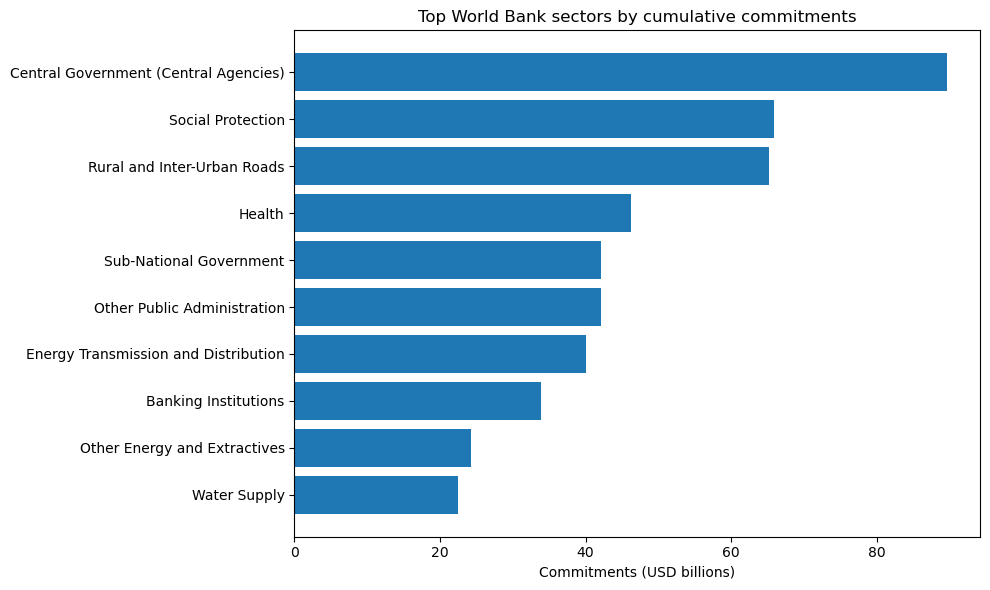

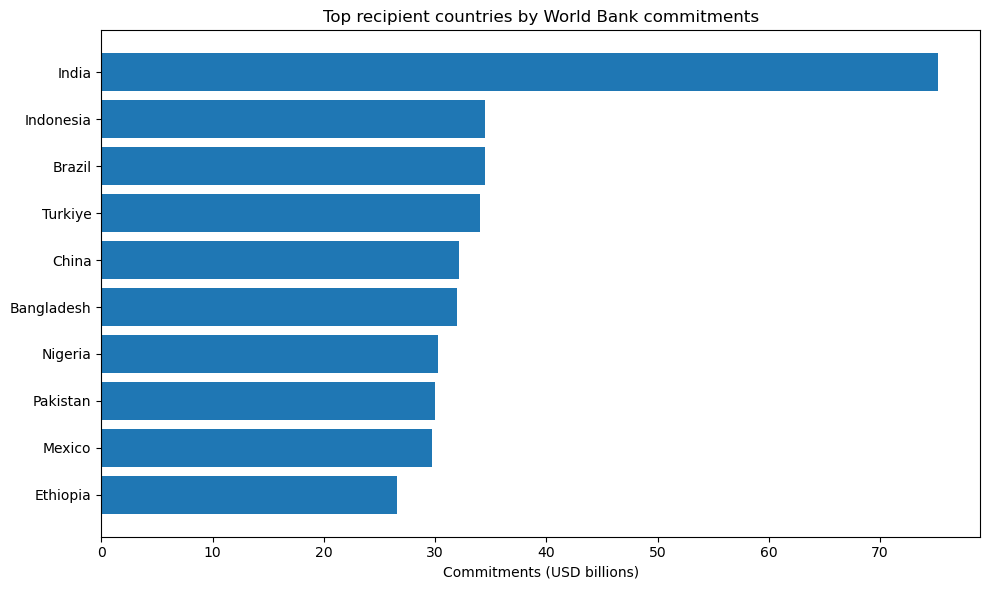

In [49]:
# Top sectors visualization
fig, ax = plt.subplots(figsize=(10,6))

top_sector_plot = (
    sector_summary
    .drop("Unknown", errors="ignore")
    .head(10)
)

ax.barh(
    top_sector_plot.index,
    top_sector_plot["total_commitments"]
)

ax.set_xlabel("Commitments (USD billions)")
ax.set_title("Top World Bank sectors by cumulative commitments")

ax.invert_yaxis()

plt.tight_layout()
plt.show()


# Top countries visualization
fig, ax = plt.subplots(figsize=(10,6))

top_country_plot = country_summary.head(10)

ax.barh(
    top_country_plot.index,
    top_country_plot["total_commitments"]
)

ax.set_xlabel("Commitments (USD billions)")
ax.set_title("Top recipient countries by World Bank commitments")

ax.invert_yaxis()

plt.tight_layout()
plt.show()

##### World Bank Dataset Structure and Concentration

The cleaned World Bank dataset contains 8,378 projects spanning 2000--2024, with broad coverage across 71 sectors and 176 countries. Funding commitments are concentrated among a relatively small number of sectors and recipient countries, with government, social, and infrastructure sectors receiving substantial funding and countries such as India, Indonesia, Brazil, Türkiye, and China accounting for large cumulative commitment totals.

In [51]:
# Check unknown sector labels
unknown_projects = wb_df[
    wb_df["sector"] == "Unknown"
]
print("Number of unknown projects:", len(unknown_projects))
print(
    "Share of projects:",
    round(len(unknown_projects) / len(wb_df) * 100, 2),
    "%"
)

unknown_projects["totalamt"].describe()
unknown_projects[
    ["project_name", "country", "year", "totalamt"]
].head(10)

Number of unknown projects: 371
Share of projects: 4.43 %


,project_name,country,year,totalamt
0,"Boosting Green Finance, Investment and Trade i...",Rwanda,2024,200000000.0
1,Chattogram Water Supply Improvement Project,Bangladesh,2024,280000000.0
2,Transforming Agri-food Systems in Morocco,Morocco,2024,250000000.0
3,"Health, Nutrition and Population Sector Develo...",Bangladesh,2024,379000000.0
4,Amaravati Integrated Urban Development Program,India,2024,0.0
5,Second Bangladesh Green and Climate Resilient ...,Bangladesh,2024,500000000.0
6,Burundi Colline Climate Resilience Project,Burundi,2024,70000000.0
7,First Zambia Climate and Economic Resilience P...,Zambia,2024,0.0
8,Togo Digital Acceleration Project,Togo,2024,100000000.0
9,Second Growth Foundations Development Policy O...,Ukraine,2024,0.0


##### Inspection of Unknown Sector Projects

Manual inspection of projects classified as ``Unknown'' suggests that these observations still contain identifiable substantive themes, including health, climate resilience, water infrastructure, agriculture, and digital development. This indicates that the category likely reflects unavailable or inconsistently assigned sector labels rather than invalid or corrupted project records. Because these projects account for only 371 observations (4.43\% of the sample), they are retained in overall commitment totals but excluded from sector-specific analyses.

### Step 4: Aggregate World Bank Data to sector x year 

In [13]:
# Aggregate World Bank commitments to sector x year

## Make sure blank sector labels are consistently coded
wb_df["sector"] = wb_df["sector"].replace("", "Unknown")

## Aggregate project-level data to sector-year level
wb_sector_year = (
    wb_df.groupby(["sector", "year"])["totalamt"]
    .sum()
    .reset_index()
    .rename(columns={"totalamt": "totalamt_sum"})
)

## Select top 8 named sectors by cumulative commitments
### Exclude Unknown because it is not substantively interpretable
top8 = (
    wb_df[wb_df["sector"] != "Unknown"]
    .groupby("sector")["totalamt"]
    .sum()
    .nlargest(8)
    .index
    .tolist()
)

## Keep sector-year observations for the top 8 named sectors
wb_top8 = (
    wb_sector_year[
        wb_sector_year["sector"].isin(top8)
    ]
    .copy()
)

## Summary table for the top 8 sectors
top8_summary = (
    wb_df[
        wb_df["sector"].isin(top8)
    ]
    .groupby("sector")
    .agg(
        n_projects=("project_id", "count"),
        total_commitments=("totalamt", "sum")
    )
    .sort_values(
        "total_commitments",
        ascending=False
    )
)

top8_summary["total_commitments_billions"] = (
    top8_summary["total_commitments"] / 1e9
)

top8_summary = top8_summary[
    ["n_projects", "total_commitments_billions"]
]

print("WB sector-year rows:", wb_sector_year.shape)

print("\nTop 8 named sectors:")
print(top8)

top8_summary

WB sector-year rows: (1240, 3)

Top 8 named sectors:
['Central Government (Central Agencies)', 'Social Protection', 'Rural and Inter-Urban Roads', 'Health', 'Sub-National Government', 'Other Public Administration', 'Energy Transmission and Distribution', 'Banking Institutions']


,n_projects,total_commitments_billions
sector,,
Central Government (Central Agencies),908,89.69417
Social Protection,606,65.81547
Rural and Inter-Urban Roads,466,65.15516
Health,520,46.27398
Sub-National Government,311,42.07054
Other Public Administration,366,42.06412
Energy Transmission and Distribution,232,40.00532
Banking Institutions,175,33.85543


##### World Bank Sector-Year Aggregation

World Bank commitments were aggregated from the project level to the sector-year level, producing 1,240 observations spanning 2000--2024. To simplify later analyses, attention was restricted to the eight sectors with the largest cumulative commitments, excluding the ``Unknown'' category from sector-specific comparisons.

The largest sectors by cumulative commitments include Central Government, Social Protection, Rural and Inter-Urban Roads, Health, and Energy Transmission and Distribution. Project counts and total commitments are not perfectly aligned across sectors, suggesting meaningful variation in average project size.

### Step 5: Build Table 1

In [14]:
table1 = pd.DataFrame({

    "Source": [
        "ECOSOC transcripts",
        "UN agency revenue",
        "World Bank projects"
    ],

    "Unit of observation": [
        "Transcript",
        "Agency-year",
        "Project"
    ],

    "Observations": [
        len(tr),
        len(un),
        len(wb_df)
    ],

    "Year range": [
        f"{tr.year.min()}–{tr.year.max()}",
        f"{un.year.min()}–{un.year.max()}",
        f"{wb_df.year.min()}–{wb_df.year.max()}"
    ],

    "Total": [
        f"{tr.n_chars.sum()/1e6:.1f}M characters",
        f"${un.revenue_usd.sum()/1e9:.1f}B revenue",
        f"${wb_df.totalamt.sum()/1e9:.1f}B commitments"
    ]
})

table1

,Source,Unit of observation,Observations,Year range,Total
0,ECOSOC transcripts,Transcript,910,2000–2025,34.0M characters
1,UN agency revenue,Agency-year,244,2011–2024,$485.2B revenue
2,World Bank projects,Project,8378,2000–2024,$910.1B commitments


Table 1 summarizes the three datasets used in the analysis. Because the datasets differ in both scale and units of observation, subsequent analyses aggregate and merge observations to create comparable structures for descriptive analysis and modeling.

### Step 6: OLS Regression

We examine whether thematic language extracted from ECOSOC discussions is associated with agency revenue. Because agency revenues are highly right-skewed, we use log-transformed revenue to reduce the influence of extreme values, stabilize variance, and allow coefficients to be interpreted approximately as proportional changes.

#### Exploratory Analysis for Predictor Selection

Before estimating OLS models, exploratory analyses examine relationships among candidate predictors, temporal patterns in thematic language, and potential multicollinearity. These analyses are intended to inform later model specification rather than mechanically select predictors.

In [39]:
# Candidate predictors
lex_cols = [
    "lex_development", "lex_humanitarian", "lex_climate",
    "lex_gender", "lex_conflict", "lex_health",
    "lex_governance"
]

control_cols = ["n_meetings", "n_tokens", "sentiment"]
candidate_cols = control_cols + lex_cols


# Build annual dataset
un_annual = un.groupby("year")["revenue_usd"].sum().reset_index()

annual_eda = t1.merge(
    un_annual,
    on="year",
    how="inner"
)

annual_eda["log_revenue"] = np.log(annual_eda["revenue_usd"])

print("Annual EDA dimensions:", annual_eda.shape)

Annual EDA dimensions: (14, 14)


In [23]:
# Correlations with revenue 
corrs = (
    annual_eda[
        candidate_cols + ["log_revenue"]
    ]
    .corr()["log_revenue"]
    .drop("log_revenue")
    .sort_values(
        key=abs,
        ascending=False
    )
)

corrs

lex_conflict        0.687043
lex_health          0.681614
lex_gender          0.643535
lex_climate         0.545469
lex_humanitarian    0.537649
lex_development    -0.494403
sentiment          -0.290079
n_meetings         -0.219589
lex_governance     -0.179930
n_tokens            0.003784
Name: log_revenue, dtype: float64

The exploratory correlations suggest meaningful variation across candidate predictors. Conflict, health, and gender language exhibit the strongest positive associations with log revenue, while development language shows a moderate negative relationship. Measures of transcript volume appear more weakly related to revenue outcomes, suggesting that thematic content may contain more information than simple activity measures. These correlations are descriptive and are used only to inform later model specification.

                  lex_development  lex_humanitarian  lex_climate  lex_gender  \
lex_development              1.00             -0.19        -0.42       -0.33   
lex_humanitarian            -0.19              1.00         0.02        0.81   
lex_climate                 -0.42              0.02         1.00       -0.09   
lex_gender                  -0.33              0.81        -0.09        1.00   
lex_conflict                -0.38              0.88         0.09        0.82   
lex_health                  -0.58              0.46         0.11        0.61   
lex_governance               0.34              0.51        -0.47        0.37   

                  lex_conflict  lex_health  lex_governance  
lex_development          -0.38       -0.58            0.34  
lex_humanitarian          0.88        0.46            0.51  
lex_climate               0.09        0.11           -0.47  
lex_gender                0.82        0.61            0.37  
lex_conflict              1.00        0.66            

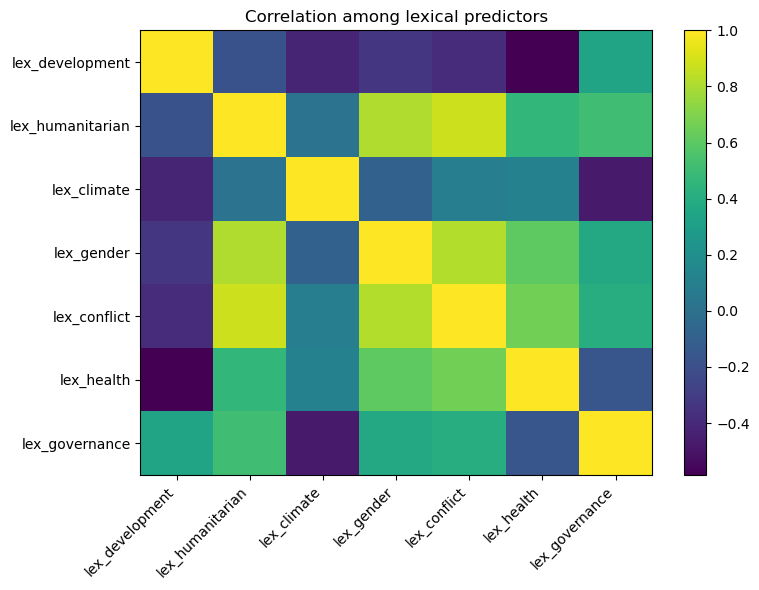

In [28]:
# Correlation among lexical predictors
corr_predictors = annual_eda[lex_cols].corr()
print(corr_predictors.round(2))

# Plot
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(corr_predictors, aspect="auto")

ax.set_xticks(range(len(corr_predictors.columns)))
ax.set_yticks(range(len(corr_predictors.columns)))

ax.set_xticklabels(
    corr_predictors.columns,
    rotation=45,
    ha="right"
)
ax.set_yticklabels(corr_predictors.columns)

plt.colorbar(im)
ax.set_title("Correlation among lexical predictors")

plt.tight_layout()
plt.show()

Several lexical predictors exhibit moderate-to-strong correlations, suggesting that some themes capture overlapping dimensions of ECOSOC discussion. Humanitarian, conflict, and gender language appear particularly closely related, while development language follows a somewhat distinct pattern. Because many thematic measures move together, including all predictors simultaneously could introduce multicollinearity, motivating more targeted model specifications.

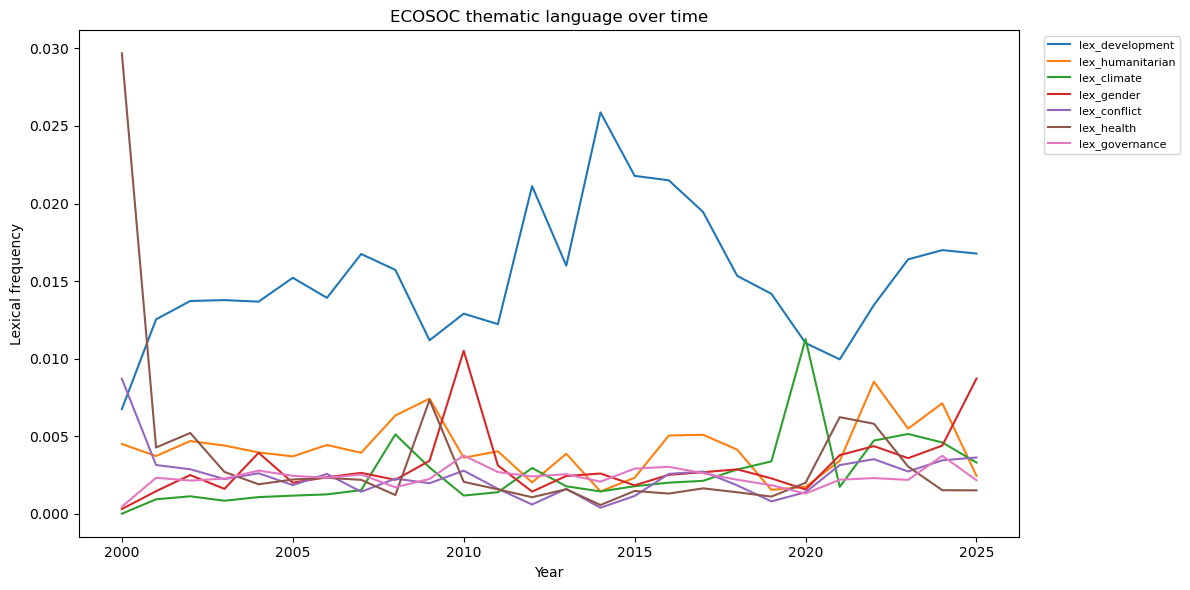

In [37]:
# Lexical trends over time
fig, ax = plt.subplots(figsize=(12,6))

for col in lex_cols:
    ax.plot(t1["year"], t1[col], label=col)

ax.set_xlabel("Year")
ax.set_ylabel("Lexical frequency")
ax.set_title("ECOSOC thematic language over time")

ax.legend(fontsize=8,
          bbox_to_anchor=(1.02,1),
          loc="upper left")

plt.tight_layout()
plt.show()

The thematic trends reveal meaningful differences in how ECOSOC discussion topics evolve over time. Development language remains consistently more prevalent and changes relatively smoothly, suggesting a broad background role in discussion. In contrast, themes such as climate, conflict, health, and gender exhibit greater variability and occasional spikes, indicating that they may reflect shorter-term shifts in emphasis or specific events. These patterns further motivate more selective model specifications rather than including all thematic measures simultaneously.

#### Fit OLS models 

##### Required Annual OLS Model: Aggregate UN Revenue and ECOSOC Discussion Themes

In [38]:
# Aggregate annual revenue
un_annual = un.groupby("year")["revenue_usd"].sum().reset_index()

# Merge features and create outcome
merged = t1.merge(un_annual, on="year")
merged["log_revenue"] = np.log(merged["revenue_usd"])

# Required regression
required_model = smf.ols(
    "log_revenue ~ lex_development + lex_gender + lex_health",
    data=merged
).fit()

print(required_model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.564
Model:                            OLS   Adj. R-squared:                  0.433
Method:                 Least Squares   F-statistic:                     4.309
Date:                Mon, 18 May 2026   Prob (F-statistic):             0.0341
Time:                        15:58:59   Log-Likelihood:                 6.7148
No. Observations:                  14   AIC:                            -5.430
Df Residuals:                      10   BIC:                            -2.873
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          24.0118      0.304     

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)


The annual OLS model explains a moderate proportion of variation in aggregate UN revenue ($R^2 = 0.564$), and the predictors are jointly significant ($p = 0.034$). However, no individual thematic variable is statistically significant, likely reflecting limited statistical power and potential multicollinearity. Because the model contains only 14 annual observations, it should be interpreted primarily as a descriptive baseline for later agency fixed-effects analyses.

#### Baseline Agency Fixed-Effects Model

Because the annual model contains few observations and does not account for systematic differences across organizations, I estimate an agency fixed-effects model:

$$
\log(\text{revenue}_{it})
=
\alpha_i
+
\beta_1\text{Development}_t
+
\varepsilon_{it}
$$

Agency fixed effects control for persistent differences across organizations, allowing the model to focus on within-agency variation over time. Development language is included as a baseline thematic predictor because exploratory analyses suggested that it represents a relatively broad and stable discussion theme.

In [27]:
# Build agency-year panel
agency_panel = un.merge(t1, on="year", how="inner")
print("Agency panel dimensions:", agency_panel.shape)

# Log outcome
agency_panel["log_revenue"] = np.log(agency_panel["revenue_usd"])

# Baseline model
baseline_model = smf.ols(
    "log_revenue ~ C(agency) + lex_development",
    data=agency_panel
).fit(
    cov_type="cluster",
    cov_kwds={"groups": agency_panel["year"]}
)

print(baseline_model.summary())

print("\nAdjusted R²:", round(baseline_model.rsquared_adj, 3))
print("AIC:", round(baseline_model.aic, 2))
print("BIC:", round(baseline_model.bic, 2))
print("Development coefficient:",
      round(baseline_model.params["lex_development"], 3))
print("Development p-value:",
      round(baseline_model.pvalues["lex_development"], 4))

Agency panel dimensions: (244, 19)
                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     1463.
Date:                Mon, 18 May 2026   Prob (F-statistic):           2.36e-18
Time:                        15:46:28   Log-Likelihood:                0.90333
No. Observations:                 244   AIC:                             38.19
Df Residuals:                     224   BIC:                             108.1
Df Model:                          19                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 19, but rank is 13
  warnings.warn('covariance of constraints does not have full '


##### Interpretation of Baseline Agency Fixed-Effects Model

The baseline model explains a large share of variation in agency revenue (adjusted $R^2 = 0.965$), suggesting that persistent differences across organizations account for much of the observed funding variation. After controlling for agency fixed effects, development language exhibits a statistically significant negative association with revenue ($\beta=-15.57$, $p=0.034$).

This relationship should be interpreted as descriptive rather than causal. The coefficient indicates that periods with greater emphasis on development-related language are associated with lower revenue levels after accounting for stable agency characteristics. Model diagnostics do not suggest severe multicollinearity concerns, although inference should be interpreted cautiously given the relatively small number of year clusters.

#### Thematic Model Specifications

To reduce multicollinearity and improve interpretability, we estimate separate thematic models rather than including all lexical variables simultaneously. The specifications examine social (gender, health), humanitarian (humanitarian, conflict), and environmental (climate) themes while retaining agency fixed effects and development language.

In [63]:
# Fit thematic models
theme_models = {
    "social":
        "log_revenue ~ C(agency) + lex_development + lex_gender + lex_health",

    "humanitarian":
        "log_revenue ~ C(agency) + lex_development + lex_humanitarian + lex_conflict",

    "environment":
        "log_revenue ~ C(agency) + lex_development + lex_climate"
}

fits = {}
results = []

for name, formula in theme_models.items():

    fit = smf.ols(
        formula,
        data=agency_panel
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": agency_panel["year"]}
    )

    fits[name] = fit

    results.append({
        "model": name,
        "adj_r2": fit.rsquared_adj,
        "aic": fit.aic,
        "bic": fit.bic
    })

model_results = pd.DataFrame(results).sort_values("aic")

model_results

,model,adj_r2,aic,bic
0,social,0.970822,-7.749644,69.188057
1,humanitarian,0.969842,0.309846,77.247547
2,environment,0.965960,28.952485,102.393018


In [64]:
# Print best model
best_model = model_results.iloc[0]["model"]

print("Best thematic model:", best_model)
print(fits[best_model].summary())

Best thematic model: social
                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     998.3
Date:                Mon, 18 May 2026   Prob (F-statistic):           2.81e-17
Time:                        16:34:18   Log-Likelihood:                 25.875
No. Observations:                 244   AIC:                            -7.750
Df Residuals:                     222   BIC:                             69.19
Df Model:                          21                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 21, but rank is 13
  warnings.warn('covariance of constraints does not have full '


In [65]:
# Compare to baseline
comparison = pd.DataFrame({
    "model": ["baseline", *model_results["model"]],
    "adj_r2": [baseline_model.rsquared_adj, *model_results["adj_r2"]],
    "aic": [baseline_model.aic, *model_results["aic"]],
    "bic": [baseline_model.bic, *model_results["bic"]]
})

comparison

,model,adj_r2,aic,bic
0,baseline,0.964515,38.193330,108.136695
1,social,0.970822,-7.749644,69.188057
2,humanitarian,0.969842,0.309846,77.247547
3,environment,0.965960,28.952485,102.393018


#### Comparison of Thematic Models

The thematic models were estimated to evaluate whether specific dimensions of ECOSOC discussion explain variation in agency revenues beyond agency fixed effects and baseline development language.

Among the thematic specifications, the social model performed best, producing the highest adjusted \(R^2\) (\(0.971\)) and the lowest AIC (\(-7.75\)) and BIC (\(69.19\)). The humanitarian model also improved model fit relative to the baseline, while the environmental model provided only modest gains.

Relative to the baseline model, adding thematic variables improved explanatory performance, suggesting that ECOSOC discussion themes contain information beyond persistent differences across agencies. Within the social model, gender language was positively associated with revenue (\(\beta=98.16\), \(p=.044\)), while health language was not statistically significant (\(p=.501\)). Development language also became statistically insignificant after adding these variables, suggesting that its earlier effect may partly reflect broader thematic patterns.

The larger condition number (\(\approx 1520\)) indicates possible multicollinearity among thematic variables, consistent with the earlier correlation analysis. Consequently, overall model fit comparisons are more informative than individual coefficient estimates.

#### Robustness Specification

To assess the sensitivity of the baseline results, I estimate a robustness model that adds transcript sentiment and meeting volume as controls. These variables account for broader differences in discussion tone and activity, helping determine whether thematic effects reflect specific content rather than general changes in communication intensity.

In [55]:
# Robustness model with transcript controls
agency_panel_robust = agency_panel.copy()

scale_cols = ["sentiment", "n_meetings"]

agency_panel_robust[scale_cols] = StandardScaler().fit_transform(
    agency_panel_robust[scale_cols]
)

robust_model = smf.ols(
    """
    log_revenue ~
    C(agency) +
    lex_gender +
    lex_health +
    sentiment +
    n_meetings
    """,
    data=agency_panel_robust
).fit(
    cov_type="cluster",
    cov_kwds={"groups": agency_panel_robust["year"]}
)

print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     1665.
Date:                Mon, 18 May 2026   Prob (F-statistic):           1.02e-18
Time:                        16:11:58   Log-Likelihood:                 35.216
No. Observations:                 244   AIC:                            -24.43
Df Residuals:                     221   BIC:                             56.00
Df Model:                          22                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 20

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 22, but rank is 13
  warnings.warn('covariance of constraints does not have full '


##### Interpretation of Robustness Specification

The robustness model explains a large proportion of variation in agency revenue (adjusted $R^2 = 0.973$), indicating that agency fixed effects continue to account for most of the model fit. Gender language remains positively and statistically significantly associated with revenue ($\beta = 114.57$, $p = 0.011$), while health language is not statistically significant. Sentiment exhibits a significant negative relationship with revenue, whereas meeting volume is only marginally significant.

Overall, the results suggest that the main findings are reasonably robust to the inclusion of additional transcript controls, although the large condition number indicates potential multicollinearity and suggests caution in interpreting individual coefficients.

### Overall OLS Findings

Three specifications were estimated:

$$
\log(\text{Revenue}_t)
=
\alpha
+
\beta_1
\text{Development}_t
+
\beta_2
\text{Gender}_t
+
\beta_3
\text{Health}_t
+
\varepsilon_t
$$

$$
\log(\text{Revenue}_{it})
=
\alpha_i
+
\beta_1
\text{Development}_t
+
\varepsilon_{it}
$$

$$
\log(\text{Revenue}_{it})
=
\alpha_i
+
\beta_1
\text{Gender}_t
+
\beta_2
\text{Health}_t
+
\beta_3
\text{Sentiment}_t
+
\beta_4
\text{Meetings}_t
+
\varepsilon_{it}
$$

The annual model explained a moderate amount of variation in aggregate UN revenue (\(R^2=.56\)), but inference is limited because only \(14\) annual observations were available.

Adding agency fixed effects substantially improved model fit (\(\text{Adjusted }R^2=.965\)), indicating that persistent organizational differences explain much of the variation in funding outcomes.

Among thematic specifications, the social model performed best (\(\text{Adjusted }R^2=.971\); lowest AIC and BIC). Gender language showed the most consistent positive association with revenue (\(p=.011\)), while health language was not statistically distinguishable from zero. Including sentiment and meeting activity did not substantially alter the substantive findings.

Overall, the results suggest that ECOSOC discussion themes contain information associated with UN funding patterns, although stable differences across agencies remain the dominant source of explained variation.

### Step 7: Save Figures 

#### ESOSOC transcript growith 

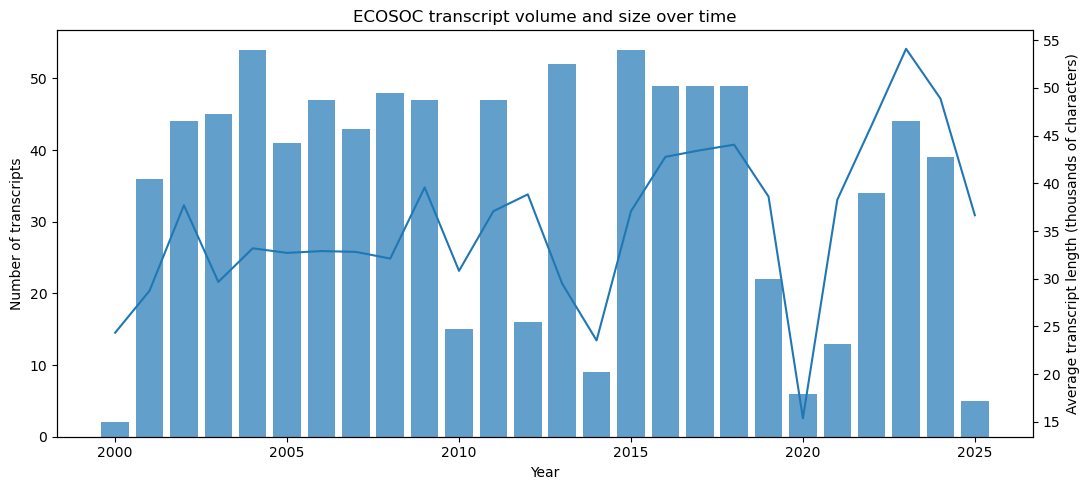

In [56]:
fig, ax1 = plt.subplots(figsize=(11,5))

# Left axis: transcript count
ax1.bar(
    by_year["year"],
    by_year["transcript_count"],
    alpha=.7
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Number of transcripts")

# Right axis: average transcript length
ax2 = ax1.twinx()

ax2.plot(
    by_year["year"],
    by_year["avg_chars"] / 1000
)

ax2.set_ylabel(
    "Average transcript length (thousands of characters)"
)

plt.title("ECOSOC transcript volume and size over time")

plt.tight_layout()
plt.savefig("../output/figures/corpus_growth.png", dpi=150)

plt.show()
plt.close()

#### Figure 2: World Bank Commitmnets by Sector 

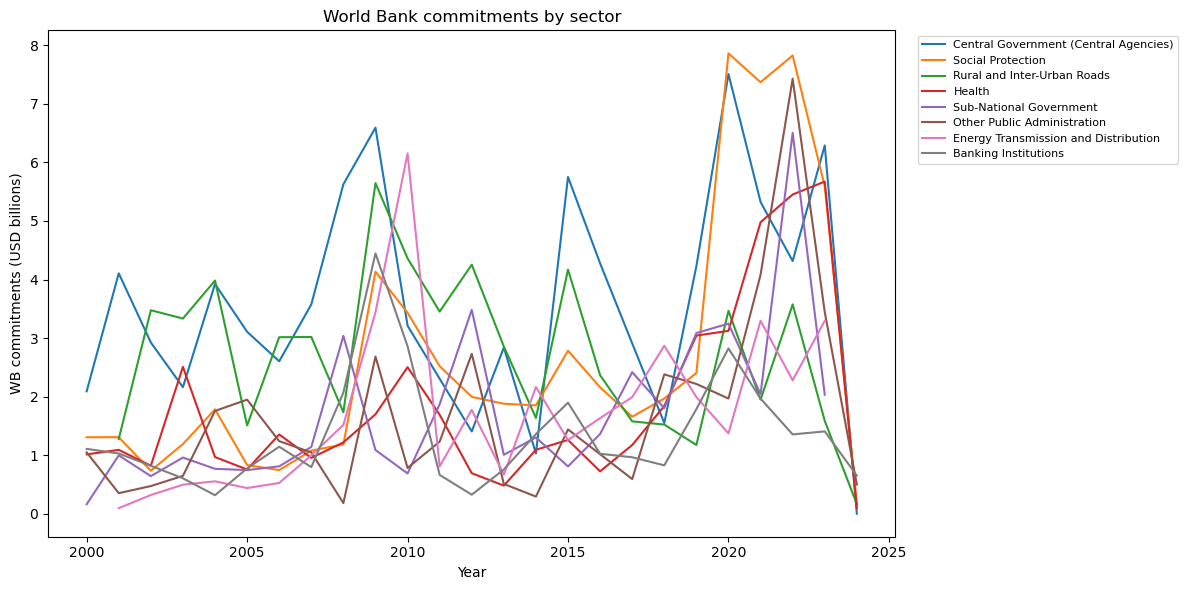

In [57]:
fig, ax = plt.subplots(figsize=(12,6))

for sector in top8:
    sub = wb_top8[wb_top8["sector"] == sector]

    ax.plot(
        sub["year"],
        sub["totalamt_sum"] / 1e9,
        label=sector
    )

ax.set_xlabel("Year")
ax.set_ylabel("WB commitments (USD billions)")
ax.set_title("World Bank commitments by sector")

ax.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "../output/figures/wb_sector_lines.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

#### Figure 3: UN agency revenue trends 

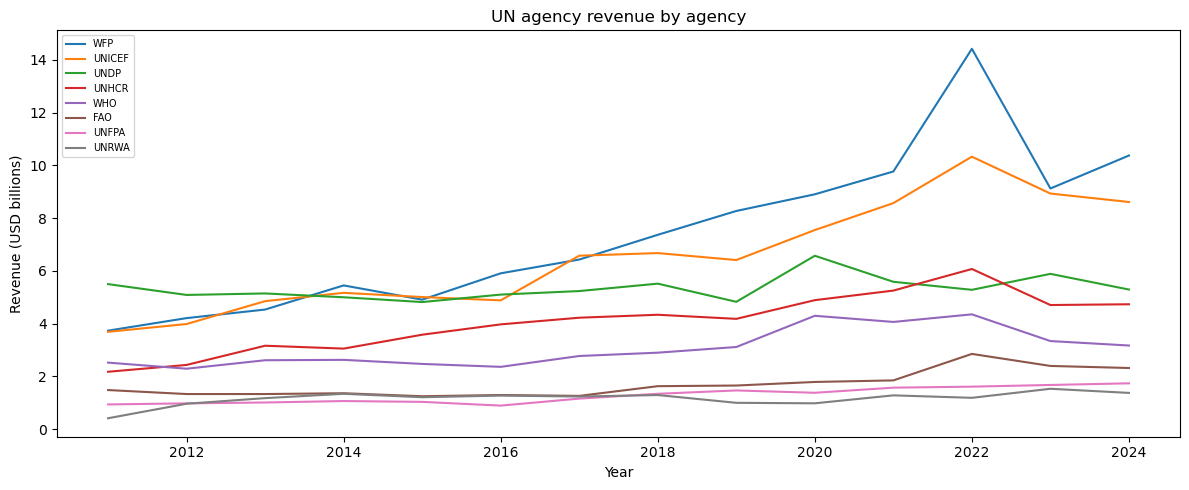

In [61]:
by_agency = (
    un.groupby("agency")["revenue_usd"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12,5))

for agency in by_agency.head(8).index:
    sub = un[un["agency"] == agency]

    ax.plot(
        sub["year"],
        sub["revenue_usd"] / 1e9,
        label=agency
    )

ax.set_xlabel("Year")
ax.set_ylabel("Revenue (USD billions)")
ax.set_title("UN agency revenue by agency")

ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig("../output/figures/un_revenue_lines.png", dpi=150)

plt.show()
plt.close()